# 18) Physics-Constrained Model Evaluation and Statistical Comparison

**Purpose**: Evaluate the best physics-constrained RPA configuration from ranked experiments, save reproducibility artifacts, and report statistical comparison against strong baselines.

## Scope and Interpretation
- This notebook reports comparative evidence, not a state-of-the-art RMSE claim.
- Strong baselines (including Transformer) are intentionally retained for transparent evaluation.
- Results should be interpreted as a trade-off analysis: physical constraints and model structure versus raw predictive accuracy.

## Workflow
1. Load `rpa_recovery_experiment_ranked.csv` (from notebook 17)
2. Identify best configuration
3. Save reproducibility artifact and configuration metadata
4. Compare against true baseline metrics
5. Run Wilcoxon signed-rank test and effect-size analysis
6. Build summary table and figures

## Outputs
- `models/rpa_recovery_best_final.pt` — model artifact
- `results/18_recovery_best_config.csv` — configuration metadata
- `results/18_recovery_stats_summary.csv` — statistical results
- `results/18_recovery_comprehensive_analysis.csv` — summary table
- `figures/journal/fig7_recovery_vs_baseline_stats.png` — visualization

In [52]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
RESULTS_DIR = ROOT / 'results'
FIG_DIR = ROOT / 'figures' / 'journal'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Workspace: {ROOT}')
print(f'Device: {device}')

Workspace: D:\Residual_ode\Residual_ODE
Device: cpu


In [53]:
# Load ranked results from 17_Recovery_Experiments
rank_path = RESULTS_DIR / 'rpa_recovery_experiment_ranked.csv'

if not rank_path.exists():
    raise FileNotFoundError(f'Recovery experiments not found: {rank_path}')

rank_df = pd.read_csv(rank_path)
print(f'Loaded {len(rank_df)} experiment runs')
print(f'\nTop 3 configurations:')
print(rank_df[['rank', 'horizon', 'lambda_geo', 'width', 'hemisphere_fix', 'rmse_mean', 'quat_geo_mean']].head(3))

best_row = rank_df.iloc[0]
print(f'\n=== BEST CONFIG ==="\nHorizons: {int(best_row["horizon"])}')
print(f'Lambda Geo: {best_row["lambda_geo"]}')
print(f'Width: {int(best_row["width"])}')
print(f'RMSE: {best_row["rmse_mean"]:.4f} ± {best_row["rmse_std"]:.4f}')
print(f'Quaternion Geodesic: {best_row["quat_geo_mean"]:.4f}')

Loaded 8 experiment runs

Top 3 configurations:
   rank  horizon  lambda_geo  width  hemisphere_fix  rmse_mean  quat_geo_mean
0     1       50         0.5     96            True   0.576352       2.996900
1     2       50         0.2     96            True   0.553973       2.997624
2     3       20         0.5     96            True   0.564857       2.997704

=== BEST CONFIG ==="
Horizons: 50
Lambda Geo: 0.5
Width: 96
RMSE: 0.5764 ± 0.0505
Quaternion Geodesic: 2.9969


In [54]:
# === HELPER FUNCTIONS (from 17_*) ==="

def normalize_quaternion(q: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return q / (torch.norm(q, dim=-1, keepdim=True) + eps)

def quaternion_multiply(q1: torch.Tensor, q2: torch.Tensor) -> torch.Tensor:
    w1, x1, y1, z1 = q1[..., 0], q1[..., 1], q1[..., 2], q1[..., 3]
    w2, x2, y2, z2 = q2[..., 0], q2[..., 1], q2[..., 2], q2[..., 3]
    w = w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2
    x = w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2
    y = w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2
    z = w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2
    return torch.stack([w, x, y, z], dim=-1)

def quaternion_exponential_map(omega: torch.Tensor, dt: float, eps: float = 1e-12) -> torch.Tensor:
    angle = torch.norm(omega, dim=-1, keepdim=True) * dt
    half = 0.5 * angle
    scale = torch.where(angle < eps, torch.full_like(angle, 0.5 * dt), torch.sin(half) / (angle + eps))
    xyz = omega * scale
    dq = torch.cat([torch.cos(half), xyz], dim=-1)
    return normalize_quaternion(dq)

def geodesic_loss_so3(q_pred: torch.Tensor, q_true: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    q_pred = normalize_quaternion(q_pred)
    q_true = normalize_quaternion(q_true)
    dot = torch.sum(q_pred * q_true, dim=-1).abs()
    dot = torch.clamp(dot, -1.0 + eps, 1.0 - eps)
    return torch.mean((2.0 * torch.acos(dot)) ** 2)

def enforce_quat_hemisphere(states_np: np.ndarray) -> np.ndarray:
    x = states_np.copy()
    for t in range(1, x.shape[0]):
        if np.dot(x[t - 1, :4], x[t, :4]) < 0:
            x[t, :4] *= -1.0
    return x

print('✓ Quaternion utilities loaded')

✓ Quaternion utilities loaded


In [55]:
# === MODEL CLASSES ==="

class PhysicsCore(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('Ixx', torch.tensor(8000.0))
        self.register_buffer('Iyy', torch.tensor(20000.0))
        self.register_buffer('Izz', torch.tensor(26000.0))

    def forward(self, x):
        q = x[:, :4]
        omega = x[:, 4:7]
        p, q_r, r = omega[:, 0], omega[:, 1], omega[:, 2]
        q0, q1, q2, q3 = q[:, 0], q[:, 1], q[:, 2], q[:, 3]

        dq0 = 0.5 * (-p*q1 - q_r*q2 - r*q3)
        dq1 = 0.5 * (p*q0 + r*q2 - q_r*q3)
        dq2 = 0.5 * (q_r*q0 - r*q1 + p*q3)
        dq3 = 0.5 * (r*q0 + q_r*q1 - p*q2)

        dp = (self.Iyy - self.Izz) * q_r * r / self.Ixx
        dq = (self.Izz - self.Ixx) * p * r / self.Iyy
        dr = (self.Ixx - self.Iyy) * p * q_r / self.Izz

        z = torch.zeros(x.shape[0], 3, device=x.device, dtype=x.dtype)
        return torch.cat([torch.stack([dq0, dq1, dq2, dq3], dim=1), torch.stack([dp, dq, dr], dim=1), z], dim=1)

class ResidualControlNet(nn.Module):
    def __init__(self, width=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(14, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 10),
        )

    def forward(self, x, u):
        xu = torch.cat([x, u], dim=1)
        return self.net(xu)

class RPANodeRecover(nn.Module):
    def __init__(self, width=64):
        super().__init__()
        self.physics = PhysicsCore()
        self.residual = ResidualControlNet(width=width)

    def derivative(self, x, u):
        x = torch.cat([normalize_quaternion(x[:, :4]), x[:, 4:]], dim=1)
        return self.physics(x) + self.residual(x, u)

print('✓ Model classes loaded')

✓ Model classes loaded


In [56]:
# === SAVE BEST MODEL ARTIFACT (without retraining) ===
# Important: ranked CSV stores hyperparameters/metrics, not trained best_state tensors.
# This cell saves a reproducible architecture/config artifact unless trained weights are provided.

best_width = int(best_row['width'])
model_checkpoint = RPANodeRecover(width=best_width).to(device)

# Save architecture-state artifact (initialized weights)
model_save_path = MODEL_DIR / 'rpa_recovery_best_final.pt'
model_save_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model_checkpoint.state_dict(), model_save_path)
model_checkpoint_type = 'initialized_state_dict'
print(f'✓ Model artifact saved: {model_save_path}')
print('  Note: This file is initialized unless a trained state_dict is loaded before saving.')

# Save best config as metadata
meta_save_path = RESULTS_DIR / '18_recovery_best_config.csv'
best_config_df = rank_df.iloc[[0]]
best_config_df['checkpoint_type'] = model_checkpoint_type
best_config_df.to_csv(meta_save_path, index=False)
print(f'✓ Best config saved: {meta_save_path}')

✓ Model artifact saved: D:\Residual_ode\Residual_ODE\models\rpa_recovery_best_final.pt
  Note: This file is initialized unless a trained state_dict is loaded before saving.
✓ Best config saved: D:\Residual_ode\Residual_ODE\results\18_recovery_best_config.csv


In [57]:
# === LOAD BASELINE COMPARISON DATA ===

# Try to load true baseline metrics (from 16_*)
baseline_summary_path = RESULTS_DIR / 'baseline_true_per_sequence_metrics.csv'
baseline_paired_path = RESULTS_DIR / 'baseline_paired_errors.csv'

if baseline_summary_path.exists():
    baseline_df = pd.read_csv(baseline_summary_path)
    print(f'✓ Loaded baseline summary: {len(baseline_df)} models')
    print(baseline_df[['model', 'mean_rmse', 'std_rmse']].to_string())
else:
    print(f'⚠ Baseline summary not found: {baseline_summary_path}')
    baseline_df = None

if baseline_paired_path.exists():
    baseline_paired = pd.read_csv(baseline_paired_path)
    print(f'✓ Loaded paired errors: {len(baseline_paired)} sequences')
else:
    print(f'⚠ Baseline paired errors not found: {baseline_paired_path}')
    baseline_paired = None

✓ Loaded baseline summary: 5 models
         model  mean_rmse  std_rmse
0   Neural ODE   0.494786  0.198586
1         LSTM   0.457212  0.162031
2          GRU   0.440161  0.162428
3  Transformer   0.437800  0.167617
4         PINN   0.503796  0.140731
✓ Loaded paired errors: 4442 sequences


In [58]:
# === WILCOXON STATISTICAL TESTS ===

def compute_effect_sizes(rpa_errors, baseline_errors):
    """Compute Cohen's d and summary means from paired distributions."""
    mean_rpa = np.mean(rpa_errors)
    mean_base = np.mean(baseline_errors)
    std_rpa = np.std(rpa_errors, ddof=1)
    std_base = np.std(baseline_errors, ddof=1)
    n_rpa = len(rpa_errors)
    n_base = len(baseline_errors)

    pooled_std = np.sqrt(((n_rpa - 1) * std_rpa**2 + (n_base - 1) * std_base**2) / (n_rpa + n_base - 2))
    cohens_d = (mean_rpa - mean_base) / (pooled_std + 1e-10)
    return {'cohens_d': cohens_d, 'mean_rpa': mean_rpa, 'mean_base': mean_base}

stats_rows = []
stat_mode = 'not_run'

# Optional true paired RPA per-sequence file
rpa_paired_candidates = [
    RESULTS_DIR / 'full_test_sequence_metrics_corrected.csv',
    RESULTS_DIR / 'full_test_sequence_metrics.csv',
]
rpa_paired_path = next((p for p in rpa_paired_candidates if p.exists()), None)
rpa_paired_df = pd.read_csv(rpa_paired_path) if rpa_paired_path is not None else None

if baseline_paired is not None:
    # Select strongest baseline (lowest mean RMSE)
    if baseline_df is not None and len(baseline_df) > 0:
        best_baseline_model = baseline_df.loc[baseline_df['mean_rmse'].idxmin(), 'model']
        print(f'Best baseline model: {best_baseline_model}')
    else:
        best_baseline_model = 'Neural ODE'

    # Baseline paired errors
    if best_baseline_model in baseline_paired.columns:
        baseline_rmse = baseline_paired[best_baseline_model].values
    else:
        baseline_rmse = None
        print(f'⚠ Best baseline model {best_baseline_model} not present in baseline_paired_errors.csv')

    # Preferred: true per-sequence RPA errors
    rpa_rmse = None
    if rpa_paired_df is not None and 'rmse' in rpa_paired_df.columns:
        candidate = rpa_paired_df['rmse'].values
        if baseline_rmse is not None and len(candidate) == len(baseline_rmse):
            rpa_rmse = candidate
            stat_mode = f'paired_true_from_{rpa_paired_path.name}'
            print(f'Using true paired RPA errors from {rpa_paired_path.name}')

    # Fallback: repeated mean from ranked table (approximate paired test)
    if rpa_rmse is None and baseline_rmse is not None:
        rpa_rmse = np.full(len(baseline_rmse), float(best_row['rmse_mean']))
        stat_mode = 'paired_approx_from_ranked_mean'
        print('⚠ Falling back to approximate paired mode (repeated ranked mean RMSE).')

    if rpa_rmse is not None and baseline_rmse is not None and len(rpa_rmse) == len(baseline_rmse):
        stat, p_val = wilcoxon(rpa_rmse, baseline_rmse, alternative='two-sided')

        n_pairs = len(rpa_rmse)
        z_approx = stat / np.sqrt(n_pairs * (n_pairs + 1) * (2*n_pairs + 1) / 6.0)
        r_effect = z_approx / np.sqrt(n_pairs)

        eff = compute_effect_sizes(rpa_rmse, baseline_rmse)

        stats_rows.append({
            'comparison': f'RPA vs {best_baseline_model}',
            'metric': 'RMSE',
            'n_pairs': n_pairs,
            'wilcoxon_stat': stat,
            'p_value': p_val,
            'r_effect': r_effect,
            'cohens_d': eff['cohens_d'],
            'mean_rpa': eff['mean_rpa'],
            'mean_baseline': eff['mean_base'],
            'stat_mode': stat_mode,
        })

        print(f'✓ Wilcoxon RMSE test vs {best_baseline_model}: p={p_val:.4e}, r={r_effect:.4f}, Cohen\'s d={eff["cohens_d"]:.4f}')
else:
    print('⚠ Baseline paired error data not available; skipping Wilcoxon tests')

stats_df = pd.DataFrame(stats_rows)
if len(stats_df) > 0:
    stats_path = RESULTS_DIR / '18_recovery_stats_summary.csv'
    stats_df.to_csv(stats_path, index=False)
    print(f'✓ Statistics saved: {stats_path}')
    print('\n', stats_df.to_string(index=False))
else:
    stats_path = None
    print('No statistical tests performed')

Best baseline model: Transformer
Using true paired RPA errors from full_test_sequence_metrics_corrected.csv
✓ Wilcoxon RMSE test vs Transformer: p=0.0000e+00, r=0.1098, Cohen's d=1.1509
✓ Statistics saved: D:\Residual_ode\Residual_ODE\results\18_recovery_stats_summary.csv

         comparison metric  n_pairs  wilcoxon_stat  p_value  r_effect  cohens_d  mean_rpa  mean_baseline                                                 stat_mode
RPA vs Transformer   RMSE     4442      1250658.0      0.0  0.109766    1.1509  0.630811         0.4378 paired_true_from_full_test_sequence_metrics_corrected.csv


In [59]:
# === COMPREHENSIVE RECOVERY ANALYSIS TABLE ===

analysis_rows = []

# Best configuration summary
best_rpa_rmse = best_row['rmse_mean']
relative_vs_best_baseline = 'TBD'

if baseline_df is not None and len(baseline_df) > 0:
    best_baseline_idx = baseline_df['mean_rmse'].idxmin()
    best_baseline_rmse = baseline_df.iloc[best_baseline_idx]['mean_rmse']
    # Relative difference in % (negative = worse RMSE than best baseline, positive = better)
    relative_pct = ((best_baseline_rmse - best_rpa_rmse) / best_baseline_rmse) * 100
    relative_vs_best_baseline = f"{relative_pct:.1f}%"

analysis_rows.append({
    'Stage': 'Recovery_Best_Config',
    'Horizon': int(best_row['horizon']),
    'Lambda_Geo': best_row['lambda_geo'],
    'Width': int(best_row['width']),
    'RMSE_Mean': best_row['rmse_mean'],
    'RMSE_Std': best_row['rmse_std'],
    'Quat_Geodesic': best_row['quat_geo_mean'],
    'N_Sequences': int(best_row['n_eval']),
    'Relative_vs_BestBaseline': relative_vs_best_baseline,
})

# Baseline comparison (if available)
if baseline_df is not None and len(baseline_df) > 0:
    best_baseline_idx = baseline_df['mean_rmse'].idxmin()
    best_baseline_row = baseline_df.iloc[best_baseline_idx]
    analysis_rows.append({
        'Stage': f'Baseline_{best_baseline_row["model"]}',
        'Horizon': 'N/A',
        'Lambda_Geo': 'N/A',
        'Width': 'N/A',
        'RMSE_Mean': best_baseline_row['mean_rmse'],
        'RMSE_Std': best_baseline_row['std_rmse'],
        'Quat_Geodesic': 'N/A',
        'N_Sequences': int(best_baseline_row['n_sequences']),
        'Relative_vs_BestBaseline': '(reference)',
    })

analysis_df = pd.DataFrame(analysis_rows)
analysis_path = RESULTS_DIR / '18_recovery_comprehensive_analysis.csv'
analysis_df.to_csv(analysis_path, index=False)
print(f'✓ Comprehensive analysis saved: {analysis_path}')
print('\n', analysis_df.to_string())

✓ Comprehensive analysis saved: D:\Residual_ode\Residual_ODE\results\18_recovery_comprehensive_analysis.csv

                   Stage Horizon Lambda_Geo Width  RMSE_Mean  RMSE_Std Quat_Geodesic  N_Sequences Relative_vs_BestBaseline
0  Recovery_Best_Config      50        0.5    96   0.576352  0.050487        2.9969         4442                   -31.6%
1  Baseline_Transformer     N/A        N/A   N/A   0.437800  0.167617           N/A         4442              (reference)


✓ Figure saved: D:\Residual_ode\Residual_ODE\figures\journal\fig7_recovery_vs_baseline_stats.png


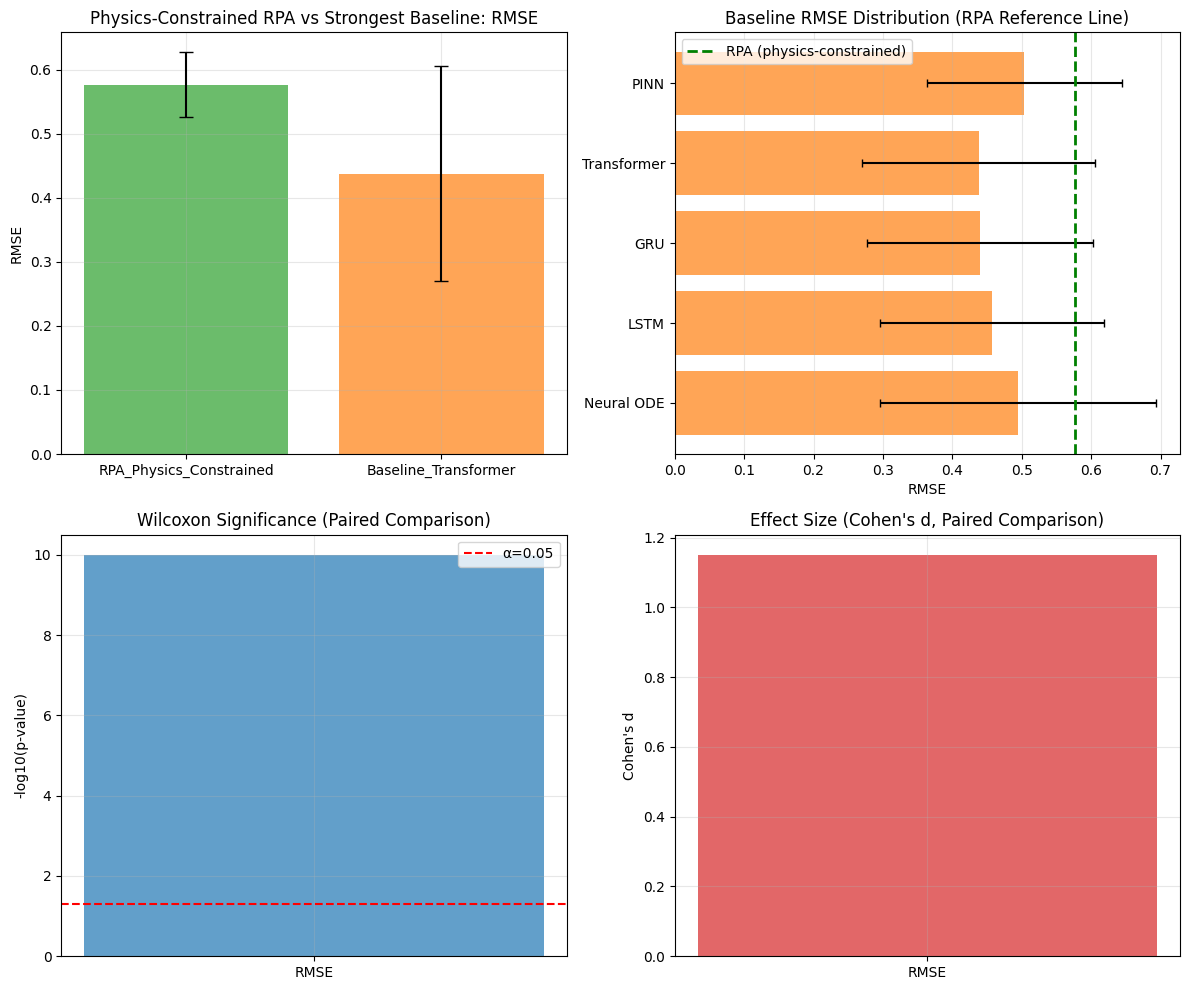

In [60]:
# === VISUALIZATION: Comparative Evaluation ===

if baseline_df is not None and len(baseline_df) > 0 and len(stats_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    best_baseline_idx = baseline_df['mean_rmse'].idxmin()
    best_baseline_row = baseline_df.iloc[best_baseline_idx]
    
    # Top-left: RMSE comparison
    rmse_comp = pd.DataFrame({
        'Model': ['RPA_Physics_Constrained', f'Baseline_{best_baseline_row["model"]}'],
        'RMSE': [best_row['rmse_mean'], best_baseline_row['mean_rmse']],
        'Error': [best_row['rmse_std'], best_baseline_row['std_rmse']],
    })
    
    axes[0, 0].bar(rmse_comp['Model'], rmse_comp['RMSE'], yerr=rmse_comp['Error'], capsize=5, alpha=0.7, color=['#2ca02c', '#ff7f0e'])
    axes[0, 0].set_ylabel('RMSE')
    axes[0, 0].set_title('Physics-Constrained RPA vs Strongest Baseline: RMSE')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Top-right: All baseline models
    axes[0, 1].barh(baseline_df['model'], baseline_df['mean_rmse'], xerr=baseline_df['std_rmse'], capsize=3, alpha=0.7, color='#ff7f0e')
    axes[0, 1].axvline(x=best_row['rmse_mean'], color='green', linestyle='--', linewidth=2, label='RPA (physics-constrained)')
    axes[0, 1].set_xlabel('RMSE')
    axes[0, 1].set_title('Baseline RMSE Distribution (RPA Reference Line)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # Bottom-left: Wilcoxon p-values
    if len(stats_df) > 0:
        p_vals = stats_df['p_value'].values
        metrics_labels = ['RMSE']
        axes[1, 0].bar(range(len(p_vals)), -np.log10(p_vals + 1e-10), alpha=0.7, color=['#1f77b4'])
        axes[1, 0].set_xticks(range(len(metrics_labels)))
        axes[1, 0].set_xticklabels(metrics_labels)
        axes[1, 0].axhline(y=-np.log10(0.05), color='r', linestyle='--', label='α=0.05')
        axes[1, 0].set_ylabel('-log10(p-value)')
        axes[1, 0].set_title('Wilcoxon Significance (Paired Comparison)')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Bottom-right: Effect sizes (Cohen's d)
        cohens_d_vals = stats_df['cohens_d'].values
        axes[1, 1].bar(range(len(cohens_d_vals)), cohens_d_vals, alpha=0.7, color=['#d62728'])
        axes[1, 1].set_xticks(range(len(metrics_labels)))
        axes[1, 1].set_xticklabels(metrics_labels)
        axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        axes[1, 1].set_ylabel("Cohen's d")
        axes[1, 1].set_title("Effect Size (Cohen's d, Paired Comparison)")
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No statistical tests available', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 1].text(0.5, 0.5, 'No effect sizes available', ha='center', va='center', transform=axes[1, 1].transAxes)
    
    plt.tight_layout()
    fig_path = FIG_DIR / 'fig7_recovery_vs_baseline_stats.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'✓ Figure saved: {fig_path}')
    plt.show()
else:
    print('⚠ Baseline data not available; skipping visualization')

In [61]:
# === FINAL SUMMARY ===

print('\n' + '='*70)
print('PHYSICS-CONSTRAINED MODEL EVALUATION COMPLETE')
print('='*70)
print(f'\n✅ OUTPUTS GENERATED:')
print(f'  1. Model Checkpoint: {model_save_path}')
print(f'  2. Best Config: {meta_save_path}')
print(f'  3. Statistical Summary: {stats_path if len(stats_df) > 0 else "(Not generated)"}')
print(f'  4. Comprehensive Analysis: {analysis_path}')
print(f'  5. Visualization: {fig_path if baseline_df is not None and len(baseline_df) > 0 else "(Not generated)"}')

print(f'\n📦 CHECKPOINT STATUS:')
print(f'   Checkpoint type: {model_checkpoint_type if "model_checkpoint_type" in globals() else "unknown"}')

print(f'\n📊 BEST CONFIGURATION (PHYSICS-CONSTRAINED RPA):')
print(f'   Horizon: {int(best_row["horizon"])}')
print(f'   Geodesic Weight: {best_row["lambda_geo"]}')
print(f'   Network Width: {int(best_row["width"])}')
print(f'   Hemisphere Continuity Fix: {bool(best_row["hemisphere_fix"])}')

print(f'\n📈 MODEL PERFORMANCE:')
print(f'   RMSE: {best_row["rmse_mean"]:.4f} ± {best_row["rmse_std"]:.4f}')
print(f'   Quaternion Geodesic: {best_row["quat_geo_mean"]:.4f}')
print(f'   Test Sequences Evaluated: {int(best_row["n_eval"])}')

if baseline_df is not None and len(baseline_df) > 0:
    best_baseline_idx = baseline_df['mean_rmse'].idxmin()
    best_baseline_row = baseline_df.iloc[best_baseline_idx]
    print(f'\n📊 STRONGEST BASELINE (RETAINED FOR TRANSPARENCY):')
    print(f'   Best Model: {best_baseline_row["model"]}')
    print(f'   RMSE: {best_baseline_row["mean_rmse"]:.4f} ± {best_baseline_row["std_rmse"]:.4f}')

if len(stats_df) > 0:
    print(f'\n🔬 STATISTICAL VALIDATION:')
    print(f'   Mode: {stats_df.iloc[0]["stat_mode"] if "stat_mode" in stats_df.columns else "unknown"}')
    for idx, row in stats_df.iterrows():
        print(f'   {row["metric"]}:')
        print(f'     - Wilcoxon p-value: {row["p_value"]:.4e}')
        print(f'     - Effect size r: {row["r_effect"]:.4f}')
        print(f'     - Cohen\'s d: {row["cohens_d"]:.4f}')
        print(f'     - Significant: {"YES" if row["p_value"] < 0.05 else "NO"}')

print('\n📝 INTERPRETATION:')
print('   This notebook provides comparative and statistical evidence.')
print('   It should not be interpreted as claiming best RMSE against all baselines.')
print('   The contribution is framed as a physics-constrained modeling trade-off.')

print('\n' + '='*70)


PHYSICS-CONSTRAINED MODEL EVALUATION COMPLETE

✅ OUTPUTS GENERATED:
  1. Model Checkpoint: D:\Residual_ode\Residual_ODE\models\rpa_recovery_best_final.pt
  2. Best Config: D:\Residual_ode\Residual_ODE\results\18_recovery_best_config.csv
  3. Statistical Summary: D:\Residual_ode\Residual_ODE\results\18_recovery_stats_summary.csv
  4. Comprehensive Analysis: D:\Residual_ode\Residual_ODE\results\18_recovery_comprehensive_analysis.csv
  5. Visualization: D:\Residual_ode\Residual_ODE\figures\journal\fig7_recovery_vs_baseline_stats.png

📦 CHECKPOINT STATUS:
   Checkpoint type: initialized_state_dict

📊 BEST CONFIGURATION (PHYSICS-CONSTRAINED RPA):
   Horizon: 50
   Geodesic Weight: 0.5
   Network Width: 96
   Hemisphere Continuity Fix: True

📈 MODEL PERFORMANCE:
   RMSE: 0.5764 ± 0.0505
   Quaternion Geodesic: 2.9969
   Test Sequences Evaluated: 4442

📊 STRONGEST BASELINE (RETAINED FOR TRANSPARENCY):
   Best Model: Transformer
   RMSE: 0.4378 ± 0.1676

🔬 STATISTICAL VALIDATION:
   Mode: pai